<Axes: xlabel='time'>

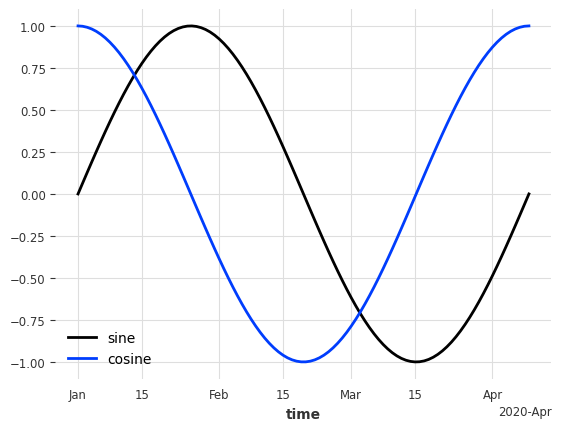

In [1]:
from darts import TimeSeries
from darts.utils.utils import generate_index
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts.datasets import AirPassengersDataset

x = np.linspace(0, 2*np.pi, 100)
s = np.sin(x)
c = np.cos(x)

dates = generate_index("2020-01-01", length=len(x), freq="D")

df = pd.DataFrame({"sine": s, "cosine": c, "time": dates})

series = TimeSeries.from_dataframe(df, time_col="time")
series.plot()

<Axes: xlabel='Month'>

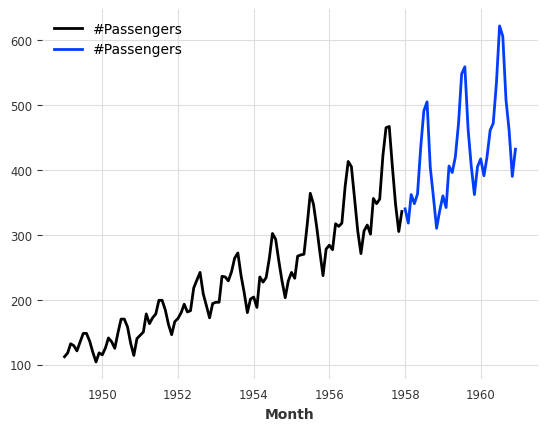

In [4]:

series = AirPassengersDataset().load()  
train, val = series.split_before(pd.Timestamp("19580101"))
train.plot()
val.plot()

model AutoARIMA() obtains MAPE: 12.703804511570299
model ExponentialSmoothing() obtains MAPE: 5.11416604412238
model Theta() obtains MAPE: 8.150284729917342


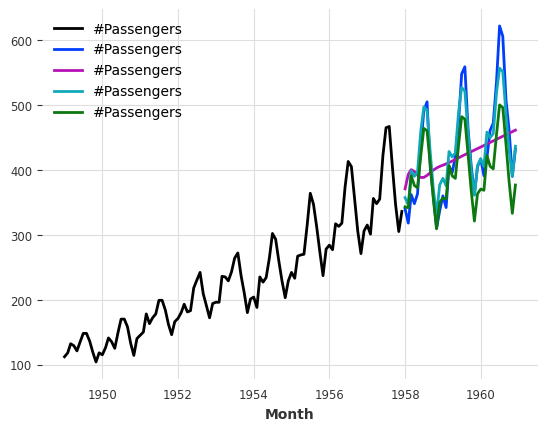

In [5]:

from darts.models import AutoARIMA, ExponentialSmoothing, Theta
from darts.metrics import mape
def eval_model(model):
    model.fit(train)
    forecast = model.predict(len(val))
    print(f"model {model} obtains MAPE: {mape(val, forecast)}")
    forecast.plot()

train.plot()
val.plot()

eval_model(AutoARIMA())
eval_model(ExponentialSmoothing())
eval_model(Theta())

Lowest MAPE is: 4.40, with theta = -3.5102040816326543.


<Axes: xlabel='Month'>

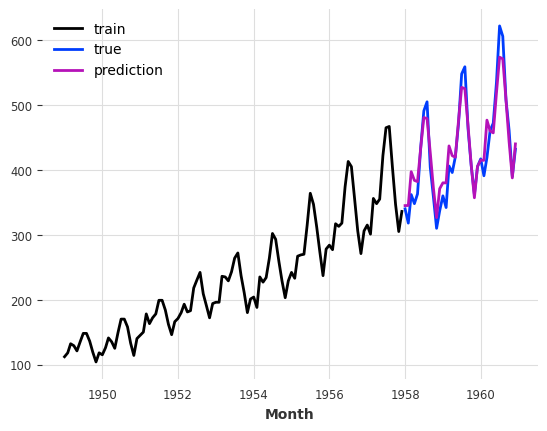

In [6]:

thetas = 2 - np.linspace(-10, 10, 50)
best_mape = float("inf")
best_theta = 0

for theta in thetas:
    model = Theta(theta)
    model.fit(train)
    pred_theta = model.predict(len(val))
    res = mape(val, pred_theta)

    if res < best_mape:
        best_mape = res
        best_theta = theta

best_theta_model = Theta(best_theta)
best_theta_model.fit(train)
pred_best_theta = best_theta_model.predict(len(val))

print(f"Lowest MAPE is: {mape(val, pred_best_theta):.2f}, with theta = {best_theta}.")

train.plot(label="train")
val.plot(label="true")
pred_best_theta.plot(label="prediction")

historical forecasts:   0%|          | 0/58 [00:00<?, ?it/s]

MAPE = 7.99%


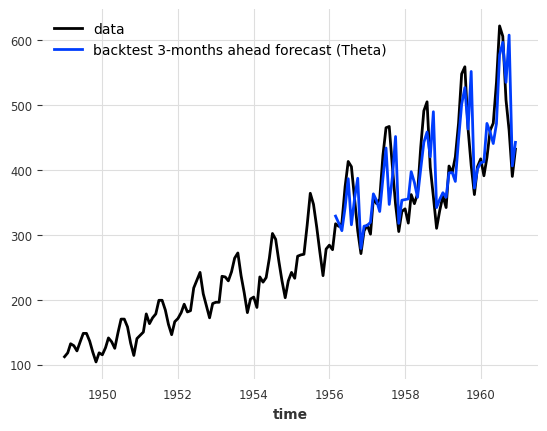

In [7]:
hfc_params = {
    "series": series,
    "start": pd.Timestamp(
        "1956-01-01"
    ),  # can also be a float for the fraction of the series to start at
    "forecast_horizon": 3,
    "verbose": True,
}
historical_fcast_theta = best_theta_model.historical_forecasts(
    last_points_only=True, **hfc_params
)

series.plot(label="data")
historical_fcast_theta.plot(label="backtest 3-months ahead forecast (Theta)")
print(f"MAPE = {mape(series, historical_fcast_theta):.2f}%")

historical forecasts:   0%|          | 0/20 [00:00<?, ?it/s]

MAPE = 5.61%


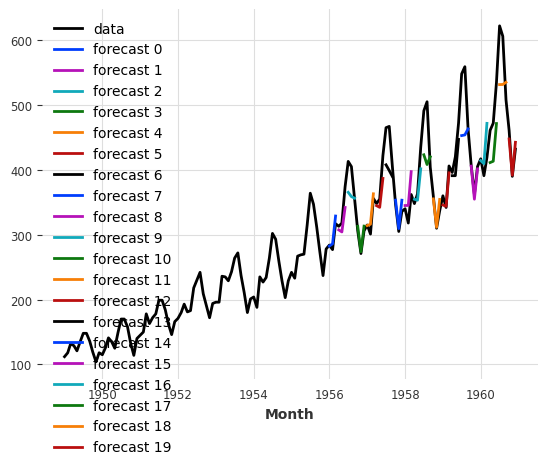

In [8]:
historical_fcast_theta_all = best_theta_model.historical_forecasts(last_points_only=False, stride=3, **hfc_params)

series.plot(label='data')
for idx, hfc in enumerate(historical_fcast_theta_all):
    hfc.plot(label=f"forecast {idx}")

from darts import concatenate

historical_fcast_theta_all = concatenate(historical_fcast_theta_all, axis=0)
print(f"MAPE = {mape(series, historical_fcast_theta_all):.2f}%")


historical forecasts:   0%|          | 0/58 [00:00<?, ?it/s]

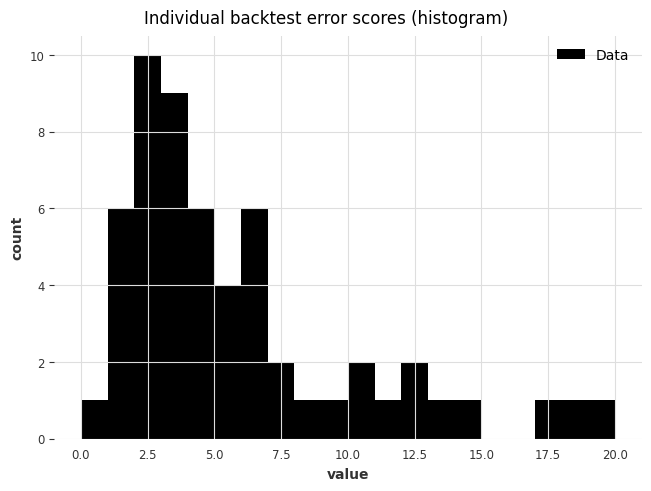

In [9]:
best_theta_model = Theta(best_theta)

raw_errors = best_theta_model.backtest(
    metric=mape, reduction=None, last_points_only=False, stride=1, **hfc_params
)

from darts.utils.statistics import plot_hist

plot_hist(
    raw_errors,
    bins=np.arange(0, max(raw_errors), 1),
    title="Individual backtest error scores (histogram)",
);

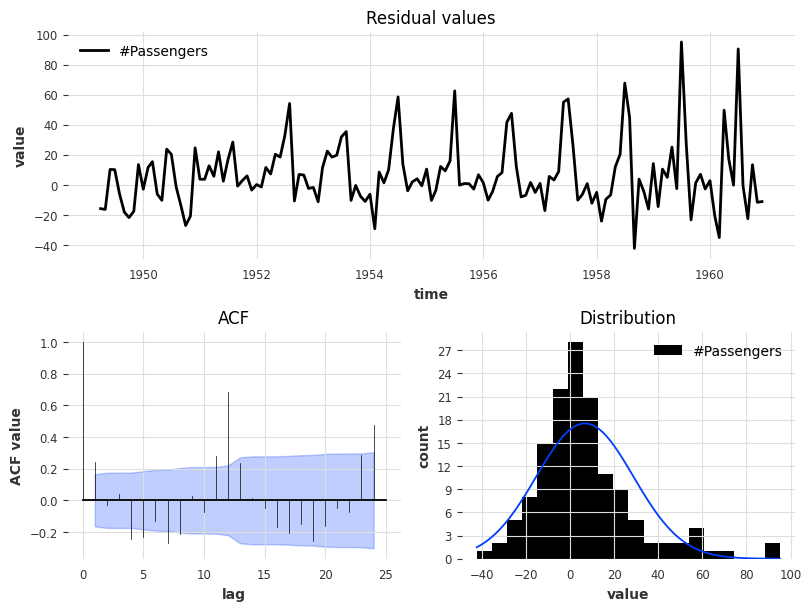

In [10]:
from darts.utils.statistics import plot_residuals_analysis

plot_residuals_analysis(best_theta_model.residuals(series))

historical forecasts:   0%|          | 0/58 [00:00<?, ?it/s]

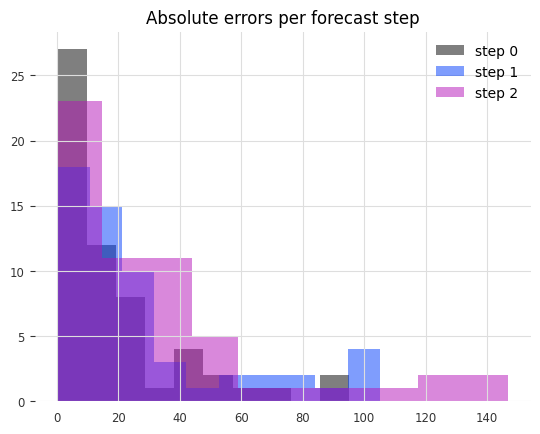

In [11]:
from darts.metrics import ae

hfc_precomputed = best_theta_model.historical_forecasts(
    last_points_only=False, stride=1, **hfc_params
)

residuals = best_theta_model.residuals(
    historical_forecasts=hfc_precomputed,
    metric=ae,  # the absolute error per time step
    last_points_only=False,
    values_only=True,  # return a list of numpy arrays
    **hfc_params,
)
residuals = np.concatenate(residuals, axis=1)[:, :, 0]

fig, ax = plt.subplots()
for forecast_step in range(len(residuals)):
    ax.hist(residuals[forecast_step], label=f"step {forecast_step}", alpha=0.5)
ax.legend()
ax.set_title("Absolute errors per forecast step");

**A toy example with two series**


These models can be trained on thousands of series. Here, for the sake of illustration, we will load two distinct series - the air traffic passenger count and another series with the number of pounds of milk produced per cow monthly. We also cast our series to np.float32 as that will slightly speedup the training:

<Axes: xlabel='Month'>

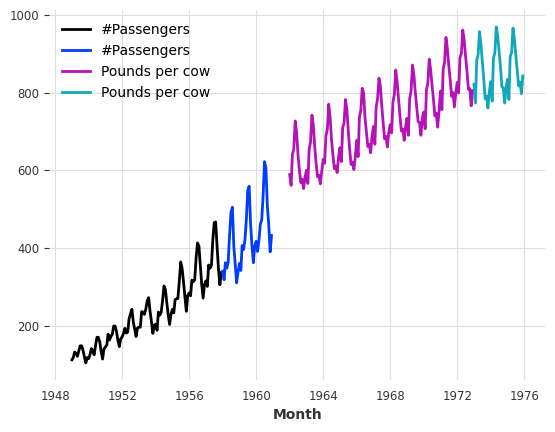

In [12]:
from darts.datasets import AirPassengersDataset, MonthlyMilkDataset

series_air = AirPassengersDataset().load().astype(np.float32)
series_milk = MonthlyMilkDataset().load().astype(np.float32)

# set aside last 36 months of each series as validation set:
train_air, val_air = series_air[:-36], series_air[-36:]
train_milk, val_milk = series_milk[:-36], series_milk[-36:]

train_air.plot()
val_air.plot()
train_milk.plot()
val_milk.plot()

<Axes: xlabel='Month'>

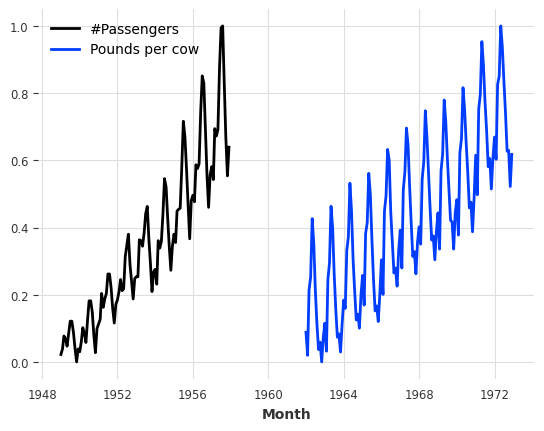

In [13]:
from darts.dataprocessing.transformers import Scaler

scaler = Scaler()
train_air_scaled, train_milk_scaled = scaler.fit_transform([train_air, train_milk])

train_air_scaled.plot()
train_milk_scaled.plot()

**Using deep learning: example with N-BEATS**

In [14]:
from darts.models import NBEATSModel

model = NBEATSModel(input_chunk_length=24, output_chunk_length=12, random_state=42)

model.fit([train_air_scaled, train_milk_scaled], epochs=50, verbose=True)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.2 M  | train
-------------------------------------------------------------
6.2 M     Trainable params
1.4 K     Non-trainable params
6.2 M     Total params
24.787    Total estimated model params size (MB)
396       Modules in train mode
0         Modules in eval mode
/Users/ralkarem/anaconda3/envs/dolEnv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on M

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


NBEATSModel(output_chunk_shift=0, generic_architecture=True, num_stacks=30, num_blocks=1, num_layers=4, layer_widths=256, expansion_coefficient_dim=5, trend_polynomial_degree=2, dropout=0.0, activation=ReLU, input_chunk_length=24, output_chunk_length=12, random_state=42)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: xlabel='Month'>

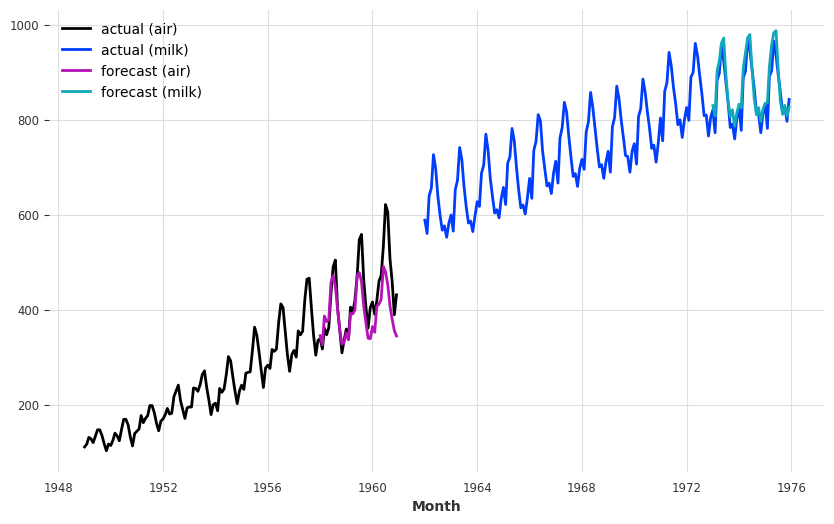

In [15]:
pred_air, pred_milk = model.predict(series=[train_air_scaled, train_milk_scaled], n=36)

# scale back:
pred_air, pred_milk = scaler.inverse_transform([pred_air, pred_milk])

plt.figure(figsize=(10, 6))
series_air.plot(label="actual (air)")
series_milk.plot(label="actual (milk)")
pred_air.plot(label="forecast (air)")
pred_milk.plot(label="forecast (milk)")

**COVARIATES**

<Axes: xlabel='Month'>

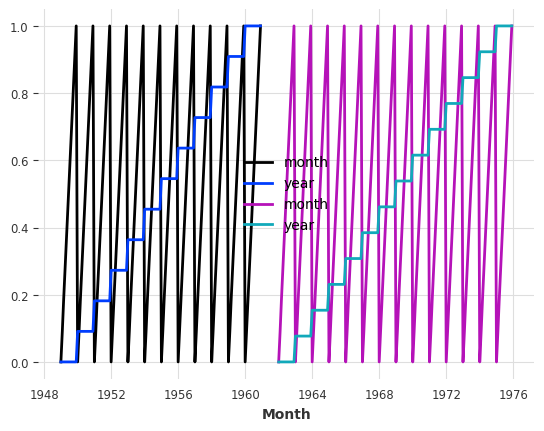

In [16]:
from darts import concatenate
from darts.utils.timeseries_generation import datetime_attribute_timeseries as dt_attr

air_covs = concatenate(
    [
        dt_attr(series_air, "month", dtype=np.float32),
        dt_attr(series_air, "year", dtype=np.float32),
    ],
    axis="component",
)

milk_covs = concatenate(
    [
        dt_attr(series_milk, "month", dtype=np.float32),
        dt_attr(series_milk, "year", dtype=np.float32),
    ],
    axis="component",
)

air_covs_scaled, milk_covs_scaled = scaler.fit_transform([air_covs, milk_covs])
air_covs_scaled.plot()
milk_covs_scaled.plot() 

In [17]:
# A different way of adding covariates is using encoders:
encoders = {"datetime_attribute": {"past": ["month", "year"]}, "transformer": Scaler()}

model = NBEATSModel(input_chunk_length=24,
                    output_chunk_length=12,
                    add_encoders=encoders,
                    random_state=42
)

model.fit(
    [train_air_scaled, train_milk_scaled], epochs=50, verbose=True)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.6 M  | train
-------------------------------------------------------------
6.6 M     Trainable params
1.7 K     Non-trainable params
6.6 M     Total params
26.314    Total estimated model params size (MB)
396       Modules in train mode
0         Modules in eval mode
/Users/ralkarem/anaconda3/envs/dolEnv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on M

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


NBEATSModel(output_chunk_shift=0, generic_architecture=True, num_stacks=30, num_blocks=1, num_layers=4, layer_widths=256, expansion_coefficient_dim=5, trend_polynomial_degree=2, dropout=0.0, activation=ReLU, input_chunk_length=24, output_chunk_length=12, add_encoders={'datetime_attribute': {'past': ['month', 'year']}, 'transformer': Scaler}, random_state=42)

In [18]:
preds = model.predict(
    series=[train_air_scaled, train_milk_scaled], n=36, show_warnings=False
)

# scale back:
pred_air, pred_milk = scaler.inverse_transform(preds)

plt.figure(figsize=(10, 6))
series_air.plot(label="actual (air)")
series_milk.plot(label="actual (milk)")
pred_air.plot(label="forecast (air)")
pred_milk.plot(label="forecast (milk)");

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/ralkarem/anaconda3/envs/dolEnv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting: |          | 0/? [00:00<?, ?it/s]

ValueError: non-broadcastable output operand with shape (36,1) doesn't match the broadcast shape (36,2)

In [19]:
from sklearn.linear_model import BayesianRidge

from darts.models import RegressionModel

model = RegressionModel(lags=72, lags_future_covariates=[-6, 0], model=BayesianRidge())

model.fit(
    [train_air_scaled, train_milk_scaled],
    future_covariates=[air_covs_scaled, milk_covs_scaled],
);

In [20]:
preds = model.predict(
    series=[train_air_scaled, train_milk_scaled],
    future_covariates=[air_covs_scaled, milk_covs_scaled],
    n=36,
)

# scale back:
pred_air, pred_milk = scaler.inverse_transform(preds)

plt.figure(figsize=(10, 6))
series_air.plot(label="actual (air)")
series_milk.plot(label="actual (milk)")
pred_air.plot(label="forecast (air)")
pred_milk.plot(label="forecast (milk)");

ValueError: non-broadcastable output operand with shape (36,1) doesn't match the broadcast shape (36,2)

**Sample Weights**

historical forecasts:   0%|          | 0/57 [00:00<?, ?it/s]

MAPE = 26.40%


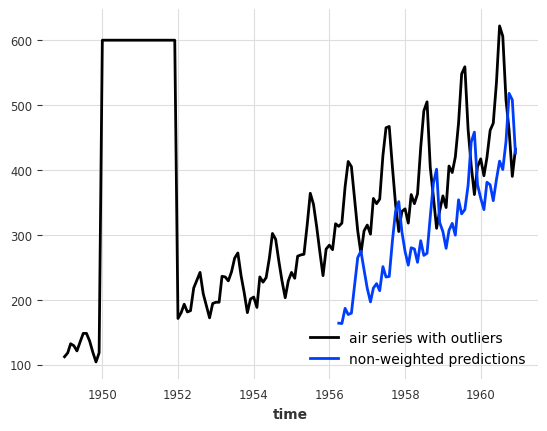

In [22]:
# convert to pandas DataFrame and add some outliers
air_df = series_air.to_dataframe()
outlier_mask = (air_df.index.year >= 1950) & (air_df.index.year <= 1951)
air_df.loc[outlier_mask] = 600.0
air_outlier = TimeSeries.from_dataframe(air_df)

from darts.models import LinearRegressionModel

model_lin = LinearRegressionModel(lags=12, lags_future_covariates=[0])
hist_fc_kwargs = {
    "series": air_outlier,
    "future_covariates": air_covs_scaled,
    "start": 0.6,
    "forecast_horizon": 3,
    "verbose": True,
    "show_warnings": False,
}
backtest = model_lin.historical_forecasts(**hist_fc_kwargs)

print(f"MAPE = {mape(air_outlier, backtest):.2f}%")
air_outlier.plot(label="air series with outliers")
backtest.plot(label="non-weighted predictions");

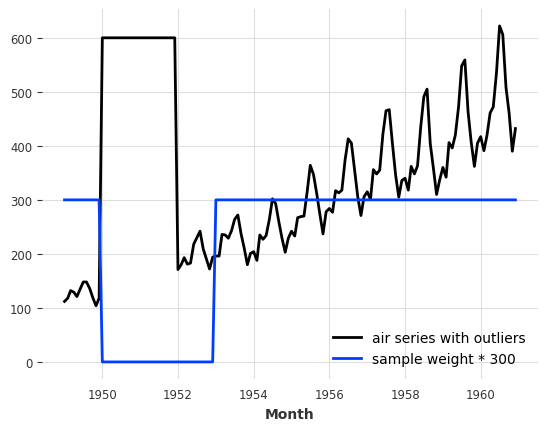

In [23]:
weight_mask = (air_df.index.year >= 1950) & (air_df.index.year <= 1952)
sample_weight = np.ones((len(air_df), 1))
sample_weight[weight_mask, 0] = 0.0
sample_weight = air_outlier.with_values(sample_weight)

# and plot the results
air_outlier.plot(label="air series with outliers")
(sample_weight * 300).plot(label="sample weight * 300");

historical forecasts:   0%|          | 0/57 [00:00<?, ?it/s]

MAPE = 5.19%


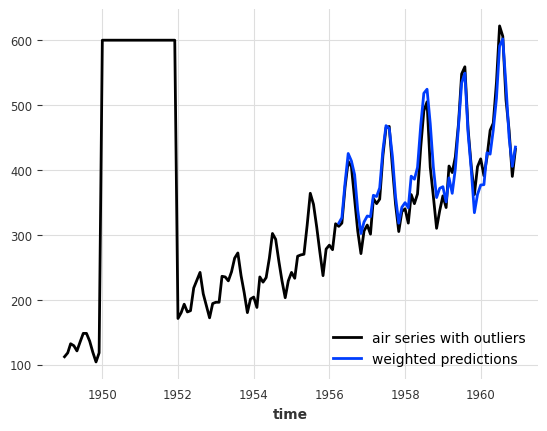

In [25]:
model_lin = LinearRegressionModel(lags=12, lags_future_covariates=[0])
backtest_weighted = model_lin.historical_forecasts(
    sample_weight=sample_weight, **hist_fc_kwargs
)
print(f"MAPE = {mape(series_air, backtest_weighted):.2f}%")
air_outlier.plot(label="air series with outliers")
backtest_weighted.plot(label="weighted predictions");

**Uncertainty Quantification (UQ)** 

For local models (ARIMA, ExponentialSmoothing, …), we can simply specify a num_samples parameter when calling predict(). The returned TimeSeries will then contain num_samples Monte Carlo samples describing the distribution of the time series’ values. The advantage of relying on Monte Carlo samples (in contrast to, say, explicit confidence intervals) is that they can be used to describe any parametric or non-parametric joint distribution over components, and compute arbitrary quantiles.

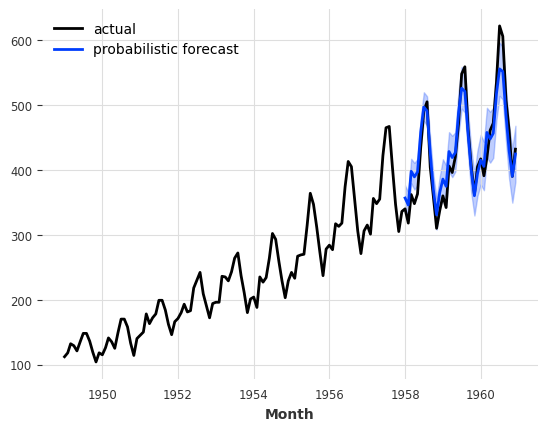

In [26]:
model_es = ExponentialSmoothing()
model_es.fit(train)
probabilistic_forecast = model_es.predict(len(val), num_samples=1000)

series.plot(label="actual")
probabilistic_forecast.plot(label="probabilistic forecast")
plt.legend()
plt.show()

In [29]:
from darts.models import TCNModel
from darts.utils.likelihood_models.torch import LaplaceLikelihood

model = TCNModel(
    input_chunk_length=24,
    output_chunk_length=12,
    random_state=42,
    likelihood=LaplaceLikelihood(),
    pl_trainer_kwargs={"accelerator": "cpu"},
)

model.fit(train_air_scaled, epochs=400, verbose=True)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/ralkarem/anaconda3/envs/dolEnv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 166    | train
-------------------------------------------------------------
166       Trainable params
0         Non-trainable params
166       Total params
0.001     Total estimated model params size (MB)
23        Modules in train mode
0         Module

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

(36, 1, 500)


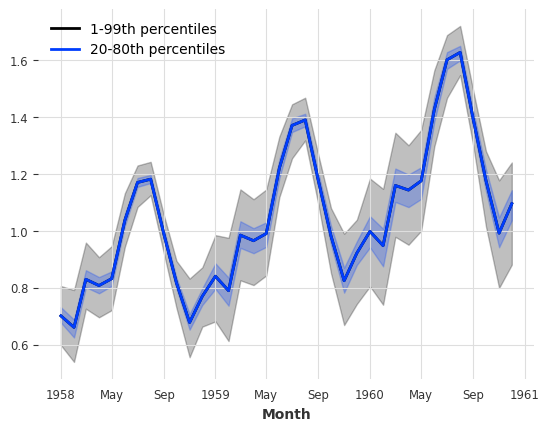

In [35]:
pred = model.predict(n=36, num_samples=500)
print(np.shape(pred))
# scale back:
# pred = scaler.inverse_transform(pred, series_idx=0)

# series_air.plot()
pred.plot(low_quantile=0.01, high_quantile=0.99, label="1-99th percentiles")
pred.plot(low_quantile=0.2, high_quantile=0.8, label="20-80th percentiles");

**Filtering Models**


<Axes: xlabel='Month'>

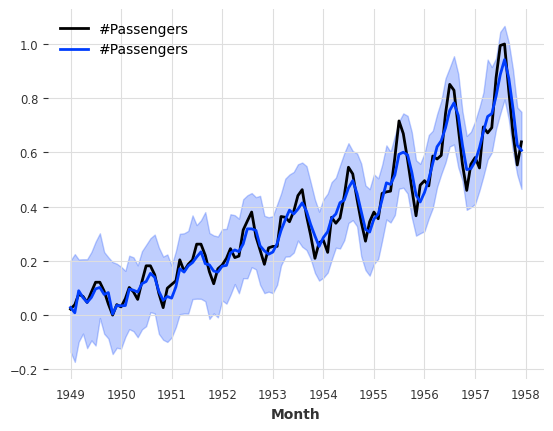

In [37]:
from darts.models import KalmanFilter

kf = KalmanFilter(dim_x=3)
kf.fit(train_air_scaled)
filtered_series = kf.filter(train_air_scaled, num_samples=100)

train_air_scaled.plot()
filtered_series.plot()

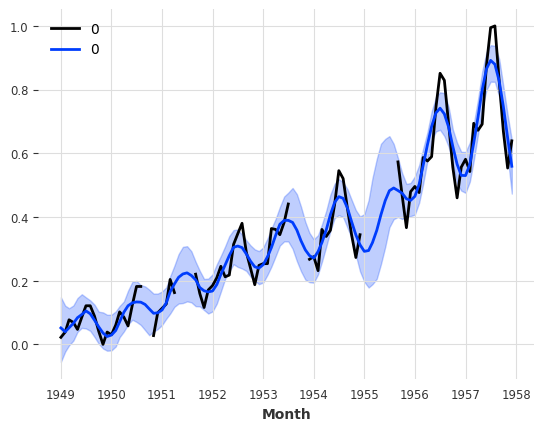

In [38]:
from sklearn.gaussian_process.kernels import RBF

from darts.models import GaussianProcessFilter

# create a series with holes:
values = train_air_scaled.values()
values[20:22] = np.nan
values[28:32] = np.nan
values[55:59] = np.nan
values[72:80] = np.nan
series_holes = TimeSeries.from_times_and_values(train_air_scaled.time_index, values)
series_holes.plot()

kernel = RBF()

gpf = GaussianProcessFilter(kernel=kernel, alpha=0.1, normalize_y=True)
filtered_series = gpf.filter(series_holes, num_samples=100)

filtered_series.plot();